In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [89]:
df=pd.read_csv('Data/Umfragedaten.csv')
df.dropna(subset=['NETTO', 'RAUCH'], inplace=True)
df.head()

,ID,GESCHL,GEBJAHR,BERUFSTAETIG,ARBEITSSTD,ARZTBES,RAUCH,GRO,GEW,SCHULABSCHLUSS,SCHULABSCHLUSS_V,SCHULABSCHLUSS_M,HOE_ABSCHLUSS,HOE_ABSCHLUSS_V,HOE_ABSCHLUSS_M,NETTO,ZUFR
0,1359,WEIBLICH,1967.0,NICHT ERWERBSTAETIG,NaN,1.0,JA,162.0,79.0,MITTLERE REIFE,MITTLERE REIFE,HOCHSCHULREIFE,LEHRE,"GEWERBL.,LANDW.LEHRE","MEISTER, TECHNIKER",475.0,10.0
1,2455,WEIBLICH,1964.0,HAUPTBERUFL.HALBTAGS,30.0,1.0,NEIN,165.0,59.0,MITTLERE REIFE,"VOLKS-,HAUPTSCHULE","VOLKS-,HAUPTSCHULE",LEHRE,"MEISTER, TECHNIKER",KAUFMAENNISCHE LEHRE,780.0,9.0
6,837,MAENNLICH,1967.0,HAUPTBERUFL.GANZTAGS,47.0,0.0,NEIN,194.0,96.0,ANDERER ABSCHLUSS,"VOLKS-,HAUPTSCHULE","VOLKS-,HAUPTSCHULE","MEISTER, TECHNIKER","GEWERBL.,LANDW.LEHRE",KEIN ABSCHLUSS,4000.0,8.0
7,1343,MAENNLICH,1989.0,NEBENHER BERUFSTAE.,NaN,1.0,NEIN,173.0,70.0,"VOLKS-,HAUPTSCHULE",OHNE ABSCHLUSS,OHNE ABSCHLUSS,KEIN ABSCHLUSS,KEIN ABSCHLUSS,KAUFMAENNISCHE LEHRE,400.0,9.0
8,3129,MAENNLICH,1960.0,HAUPTBERUFL.GANZTAGS,37.0,0.0,NEIN,175.0,85.0,"VOLKS-,HAUPTSCHULE","VOLKS-,HAUPTSCHULE","VOLKS-,HAUPTSCHULE",LEHRE,"GEWERBL.,LANDW.LEHRE",KAUFMAENNISCHE LEHRE,1100.0,8.0


In [90]:
x=df['NETTO'].values.reshape(-1,1)
y=(df['RAUCH'] == 'JA').astype(int).values

In [91]:
x=x[:,0]
print(np.any(np.isnan(x)))
print(np.any(np.isnan(y)))

False
False


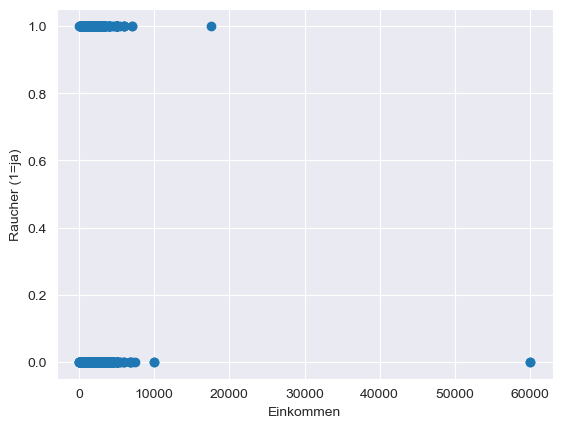

In [92]:
plt.plot(x,y,'o')
plt.xlabel('Einkommen')
plt.ylabel('Raucher (1=ja)')
plt.show()

In [107]:
#train the model
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x.reshape(-1,1),y,test_size=0.05,random_state=0)

In [108]:
logreg = LogisticRegression(penalty=None)
logreg.fit(X_train, y_train)

y_pred=logreg.predict(X_test)
y_pred2 = logreg.predict_proba(X_test)[:,1]

print(logreg.coef_, logreg.intercept_)

[[1.26036084e-05]] [-0.89827045]


In [110]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[94,  0],
       [42,  0]])

In [112]:
tn, fp, fn, tp = cnf_matrix.ravel()
print(f"tn: {tn},fp: {fp},fn: {fn},tp:{tp}")

tn: 94,fp: 0,fn: 42,tp:0


In [96]:
tn, fp, fn, tp = cnf_matrix.ravel()
print(tn,fp,fn,tp)

94 0 42 0


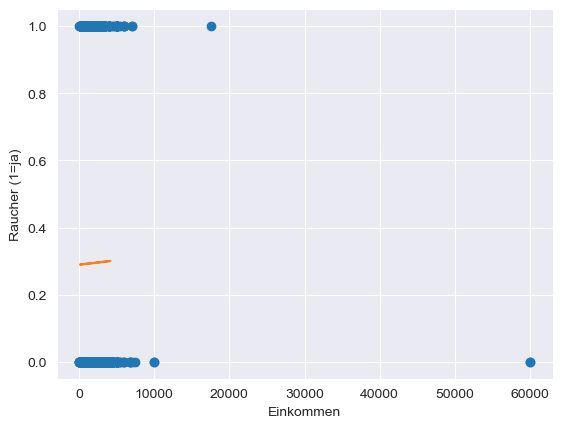

In [97]:
plt.plot(x,y,'o')
plt.plot(X_test,y_pred2)
plt.xlabel('Einkommen')
plt.ylabel('Raucher (1=ja)')
plt.show()

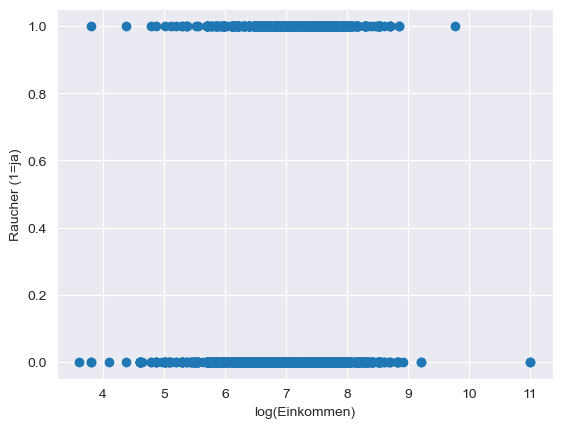

In [98]:
plt.plot(np.log(x),y,'o')
plt.xlabel('log(Einkommen)')
plt.ylabel('Raucher (1=ja)')
plt.show()


In [117]:
xnew2 = np.log(x)
X_train,X_test,y_train,y_test = train_test_split(xnew2.reshape(-1,1),y,test_size=0.25, random_state=0)
# logistic regression
logreg = LogisticRegression(penalty=None)
# fit the model with data
logreg.fit(X_train,y_train)
#
y_pred=logreg.predict(X_test)
y_pred2 = logreg.predict_proba(X_test)[:,1]
print(logreg.coef_, logreg.intercept_)

[[0.15448143]] [-1.98614602]


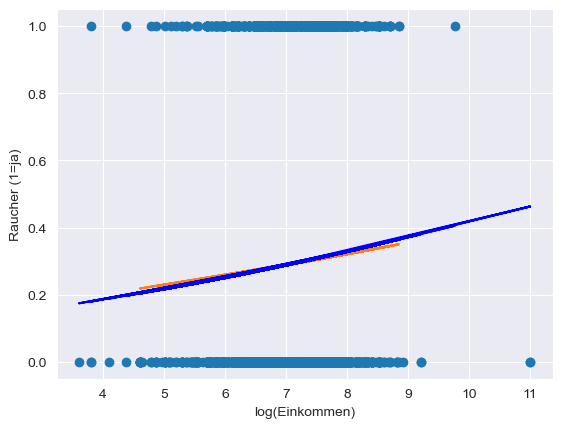

In [119]:
#create the model manually to verify the prediction of python works (yes, it's the same)
pi = np.exp(-2.24+.19*xnew2) / (1+np.exp(-2.24+.19*xnew2))
#plotting
#show a scatter plot
plt.plot(xnew2,y,'o')
plt.plot(X_test,y_pred2)
plt.plot(xnew2,pi,color='b')
plt.xlabel('log(Einkommen)')
plt.ylabel('Raucher (1=ja)')
plt.show()


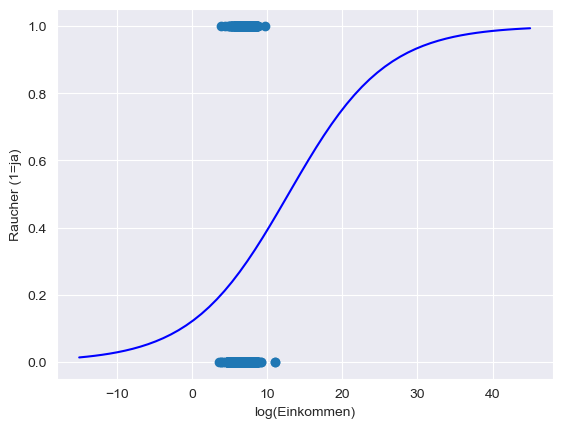

In [101]:
#plot a larger x-axis to see the full model
xlarge = np.linspace(-15,45,60).reshape((-1,1))
ylarge = logreg.predict_proba(xlarge)[:,1]
plt.plot(xnew2,y,'o')
plt.plot(xlarge,ylarge,color='b')
plt.xlabel('log(Einkommen)')
plt.ylabel('Raucher (1=ja)')
plt.show()
#yes, the model is a logit model, but the data are not clearly separated, which means it doesn't fit too well
# We also see that the model would always predict a nonsmoker within our data range.

In [102]:
#wahrscheinlichkeit bei 2000 gehalt [%]
#predict() predicts a value, predict_proba predicts the probability
#I could not find a way to make it work with just 1 value, therefore I made
#an array and will ignore the result for 2001 below.
val = np.log(np.array([2000,2001]))
print(np.log(2000))
print((logreg.predict_proba(val.reshape(-1,1))*100.)[0])
#7.6 ist der x-Achsenwert
#die zweite Zahl, also 31.1 ist die Wahrscheinlichkeit.

7.600902459542082
[69.25243968 30.74756032]
